In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q qiskit[visualization]
!pip install -q qiskit_aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 64.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.0 MB/s eta 0:00:00:00:0100:01


In [3]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
%matplotlib inline
import math
from qiskit_aer import AerSimulator

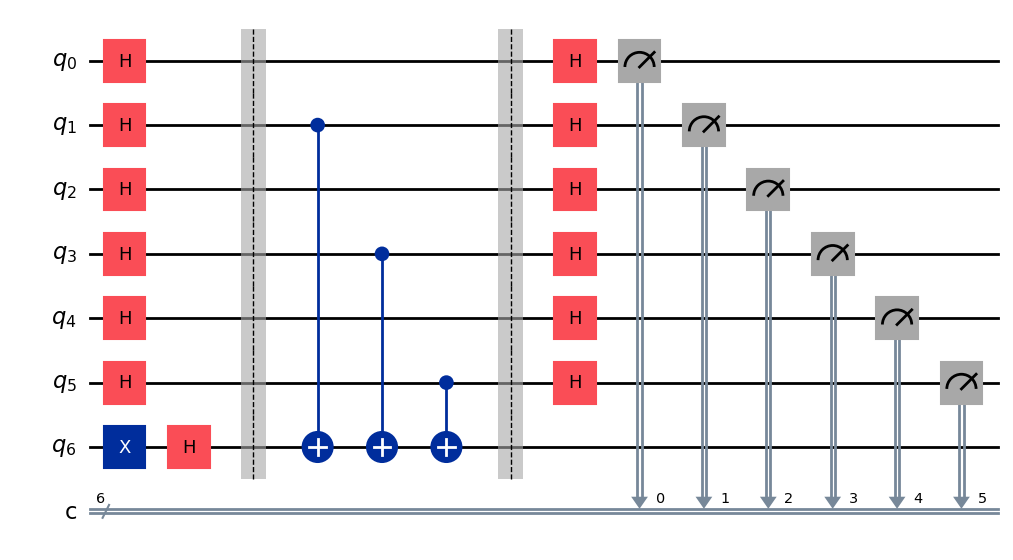

In [4]:
# baby impl of Bernstein Vazirani number predctor in one shot
# classical computer will take n shots for n bits

input_number = '101010' # 42 :-)

qc = QuantumCircuit(7, 6) # 7 qubits and 6 classical bits. 1 ancilla qubit
qc.h([0,1,2,3,4,5])
qc.x(6)
qc.h(6)
qc.barrier()

qc.cx(1,6)
qc.cx(3,6)
qc.cx(5,6)
qc.barrier()

qc.h([0,1,2,3,4,5])

qc.measure([0,1,2,3,4,5], [0,1,2,3,4,5])

qc.draw(output='mpl')


In [5]:
qasm_sim = AerSimulator()
result = qasm_sim.run(qc, shots=1).result()
counts = result.get_counts(qc)
print(counts)

{'101010': 1}


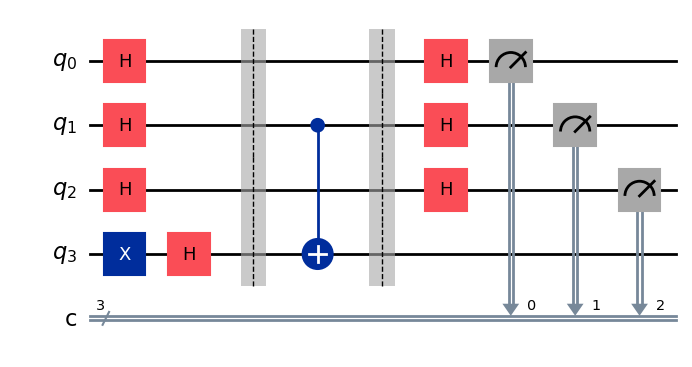

In [18]:
# improving and generalizing the code

from qiskit import *
from qiskit.visualization import plot_bloch_multivector, plot_histogram
%matplotlib inline
import math
from qiskit_aer import AerSimulator


# baby impl of Bernstein Vazirani number predctor in one shot
# classical computer will take n shots for n bits

input_number = '010' # 42 :-)

num_qbits = len(input_number)
qbits = range(num_qbits)

qc = QuantumCircuit(num_qbits+1, num_qbits) # 7 qubits and 6 classical bits. 1 ancilla qubit
qc.h(qbits)
qc.x(num_qbits)
qc.h(num_qbits)
qc.barrier()

for index, val in enumerate(reversed(input_number)):
    if val == '1':
        qc.cx(index, num_qbits)

qc.barrier()
qc.h(qbits)
qc.measure(qbits, qbits) # brevity using qbits for classical as well

qc.draw(output='mpl')


In [19]:
qasm_sim = AerSimulator()
result = qasm_sim.run(qc, shots=1).result()
counts = result.get_counts(qc)
print("Guessing the number in 1 shot")
print(counts)

Guessing the number in 1 shot
{'010': 1}


# the mathematical explanation for 010 as input


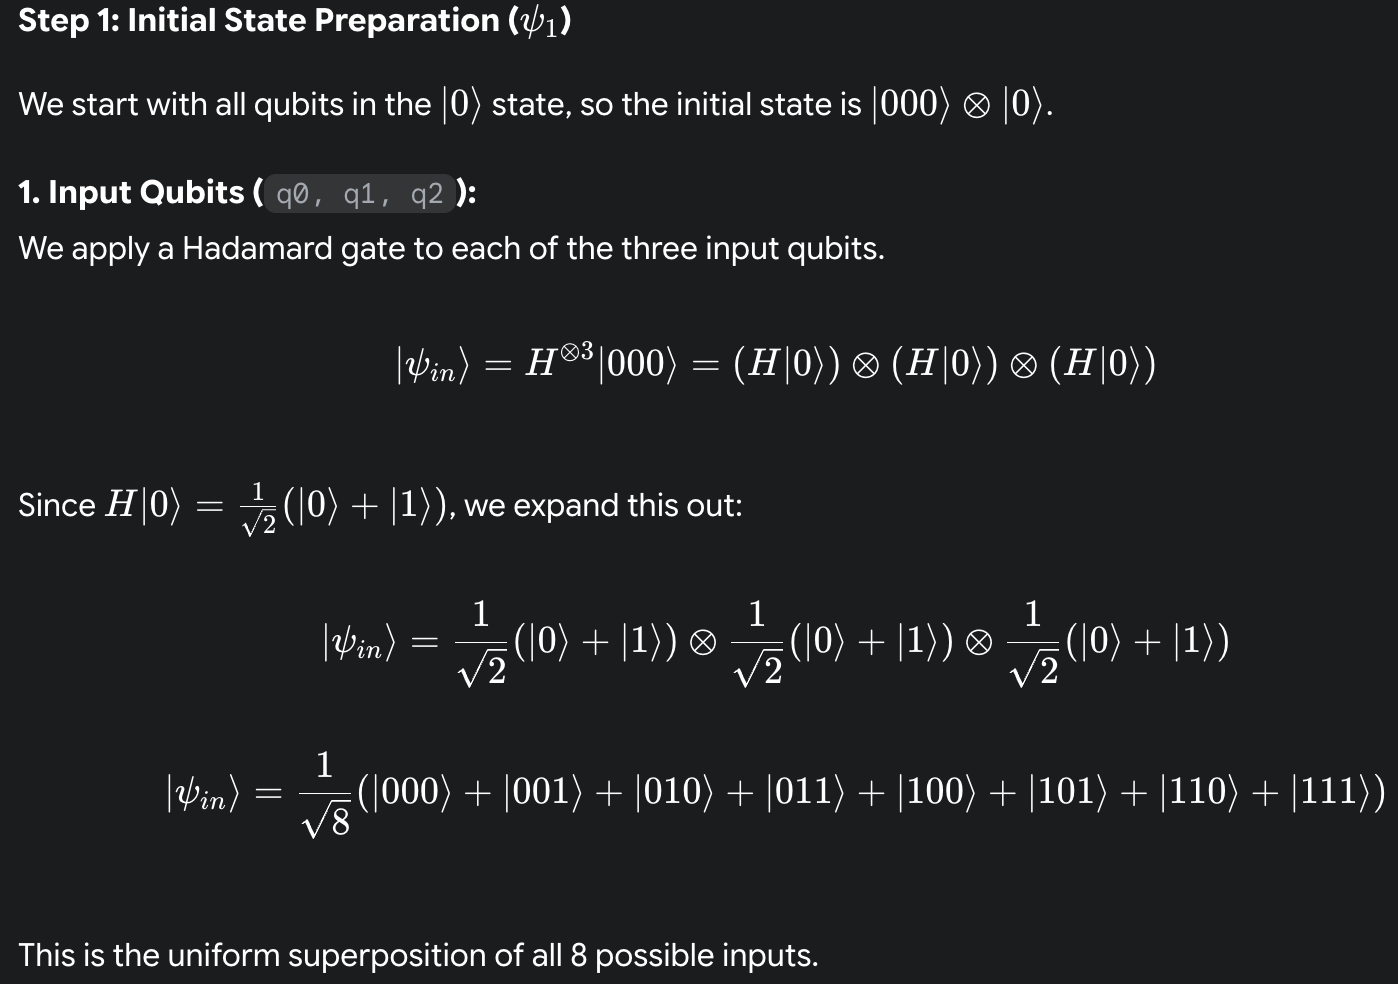

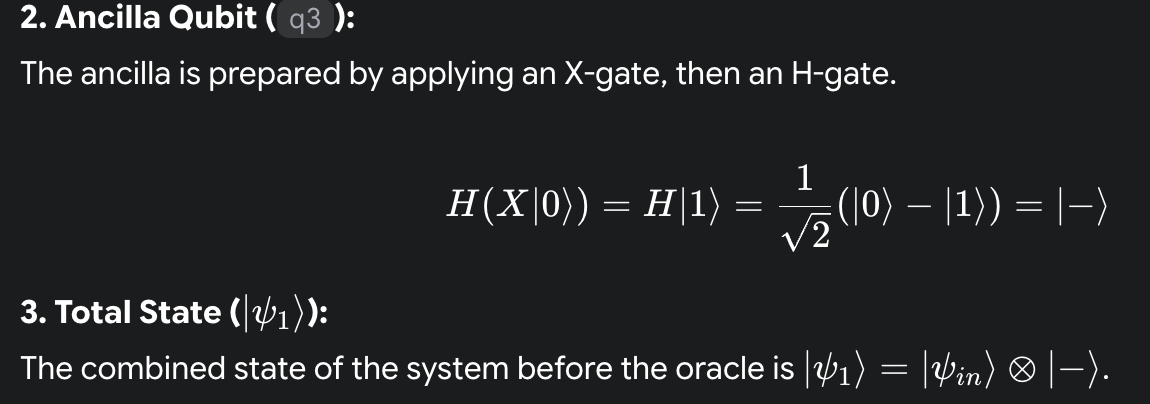

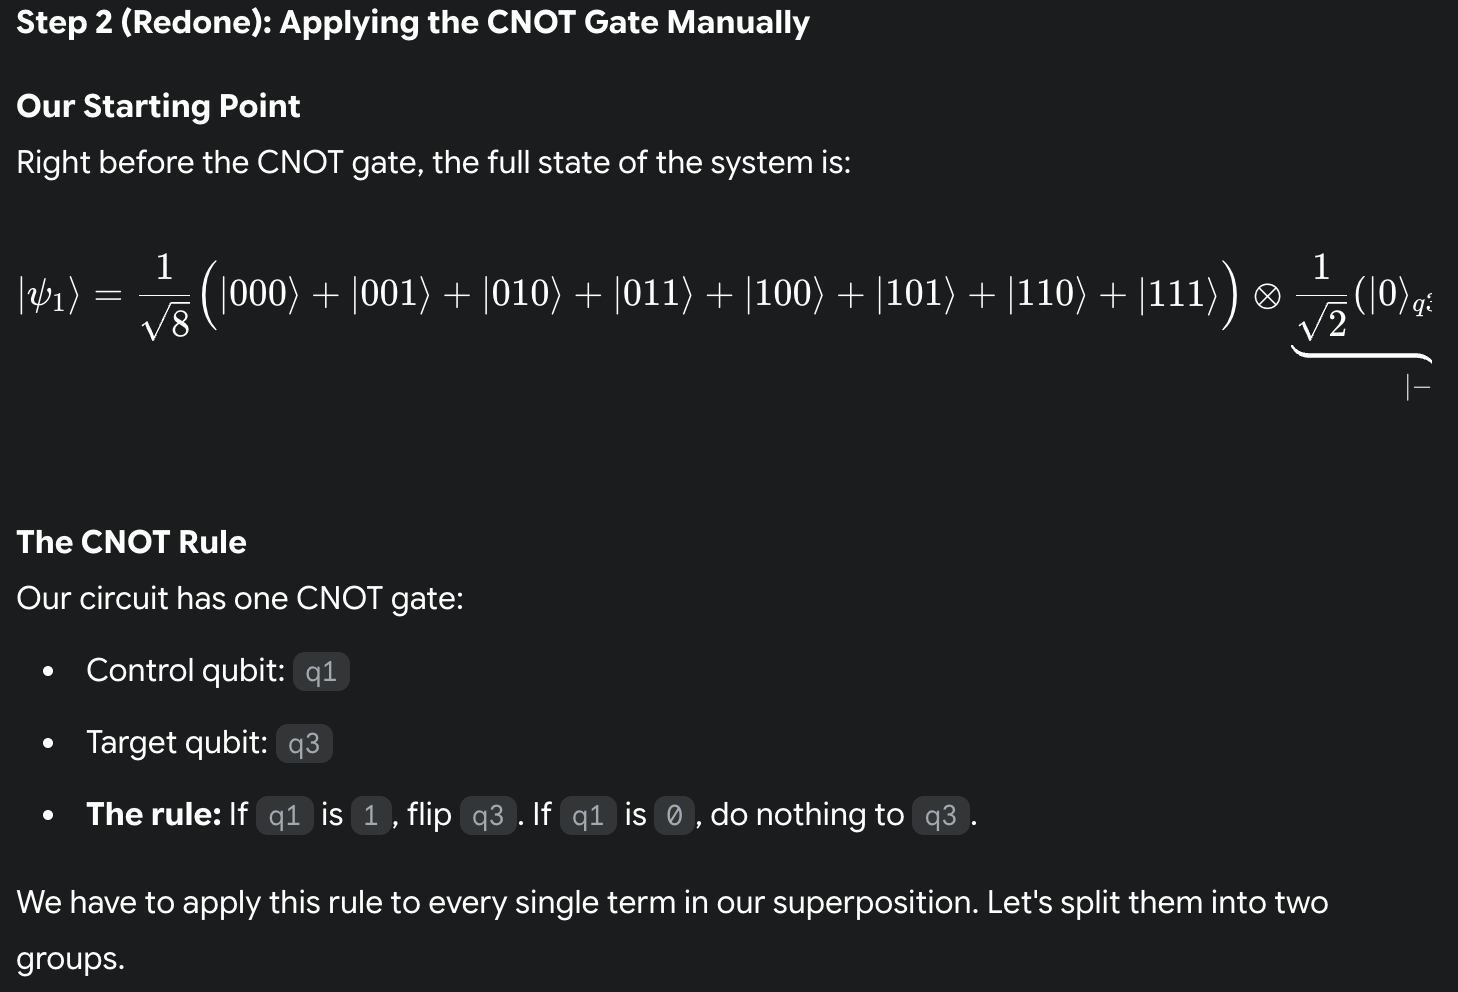

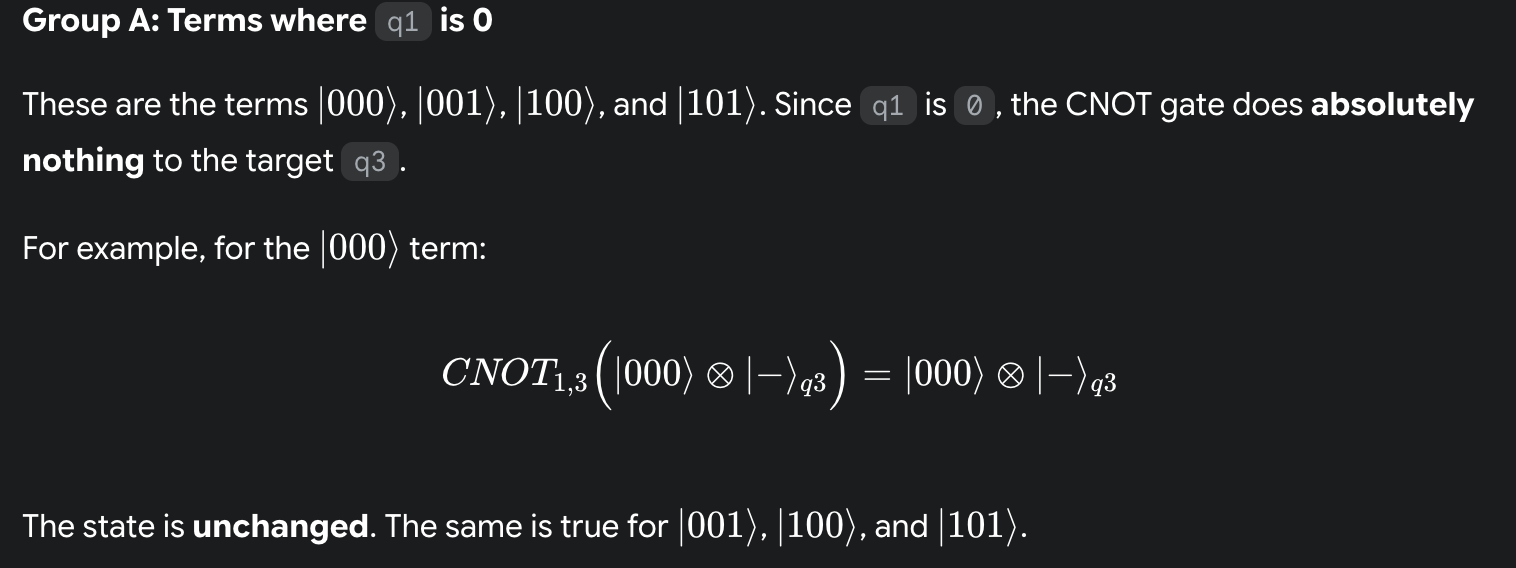

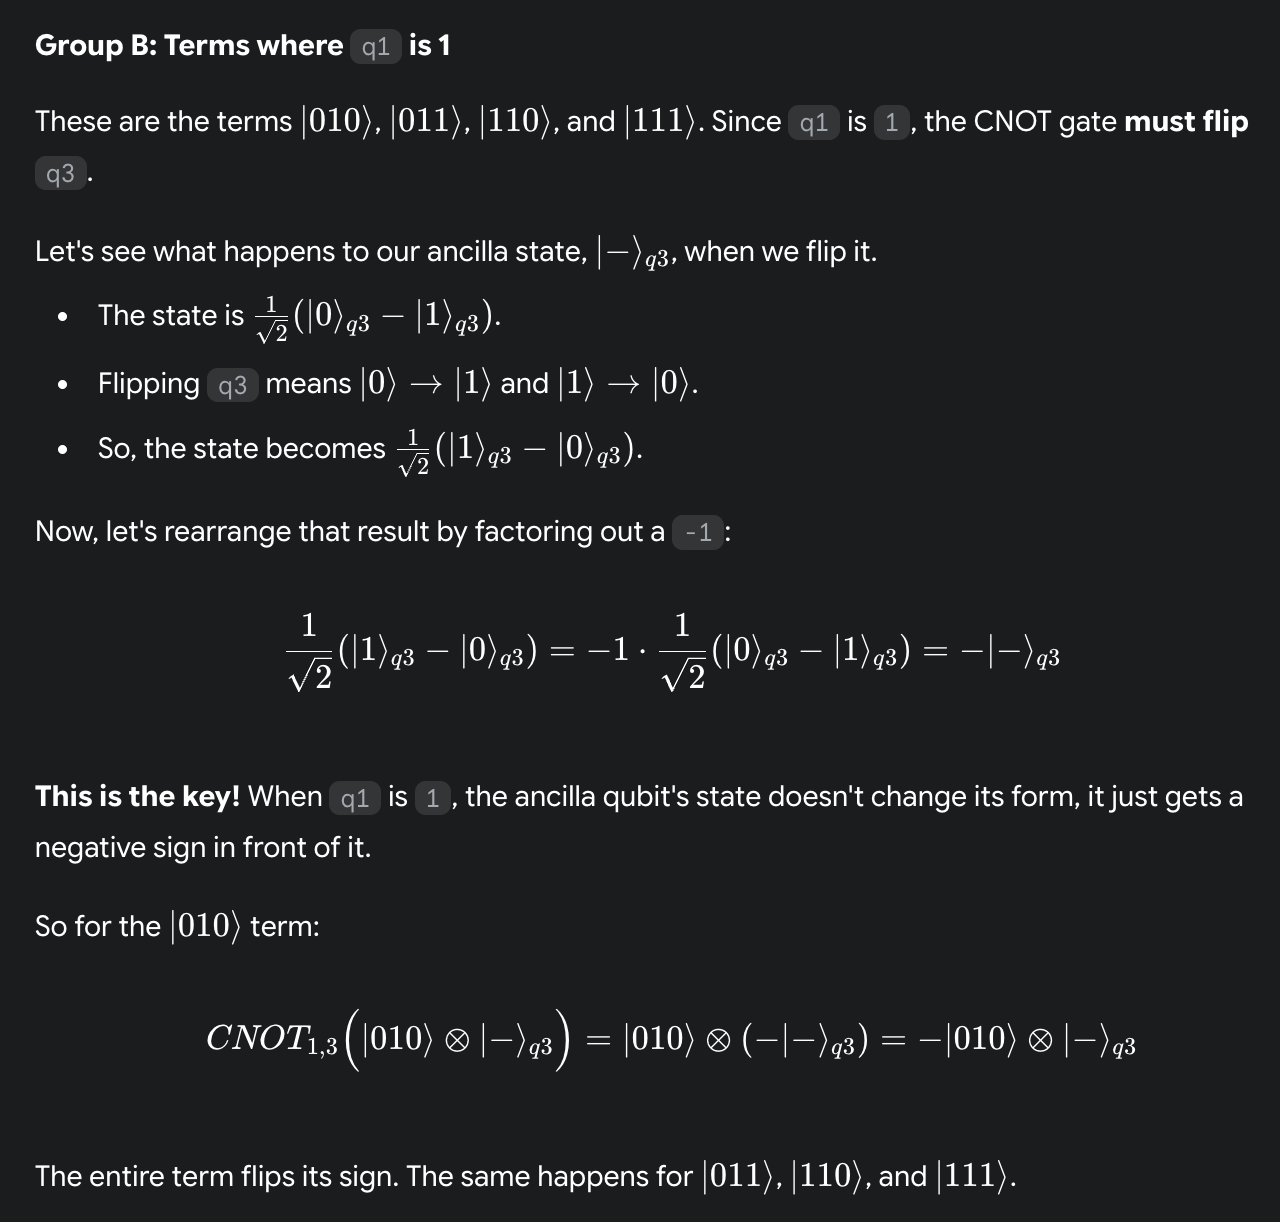

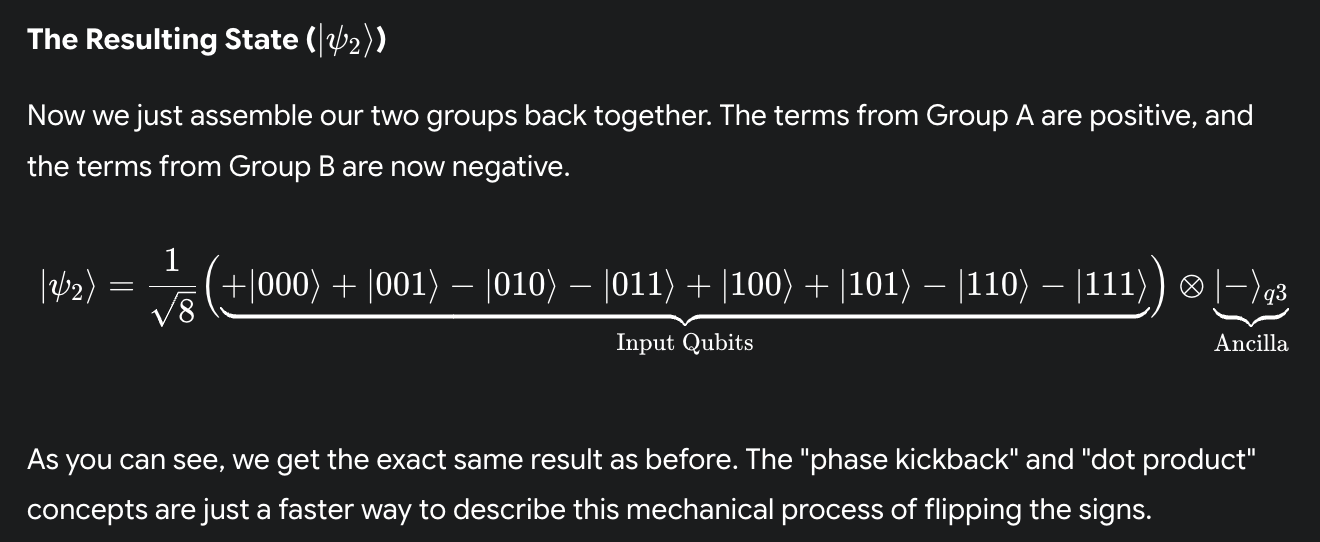

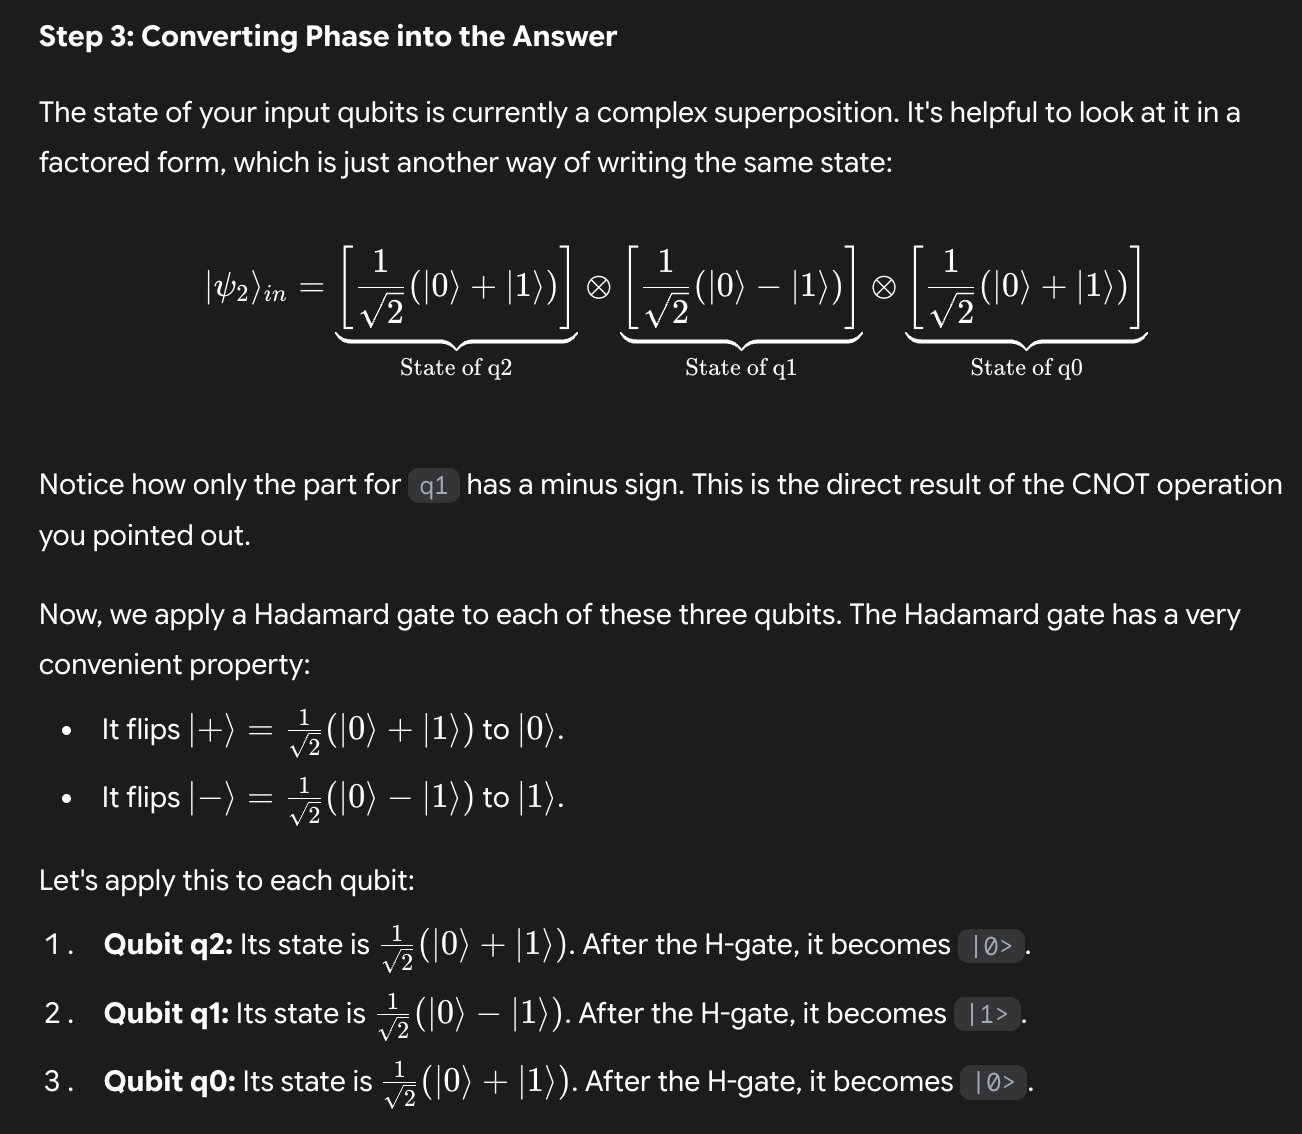

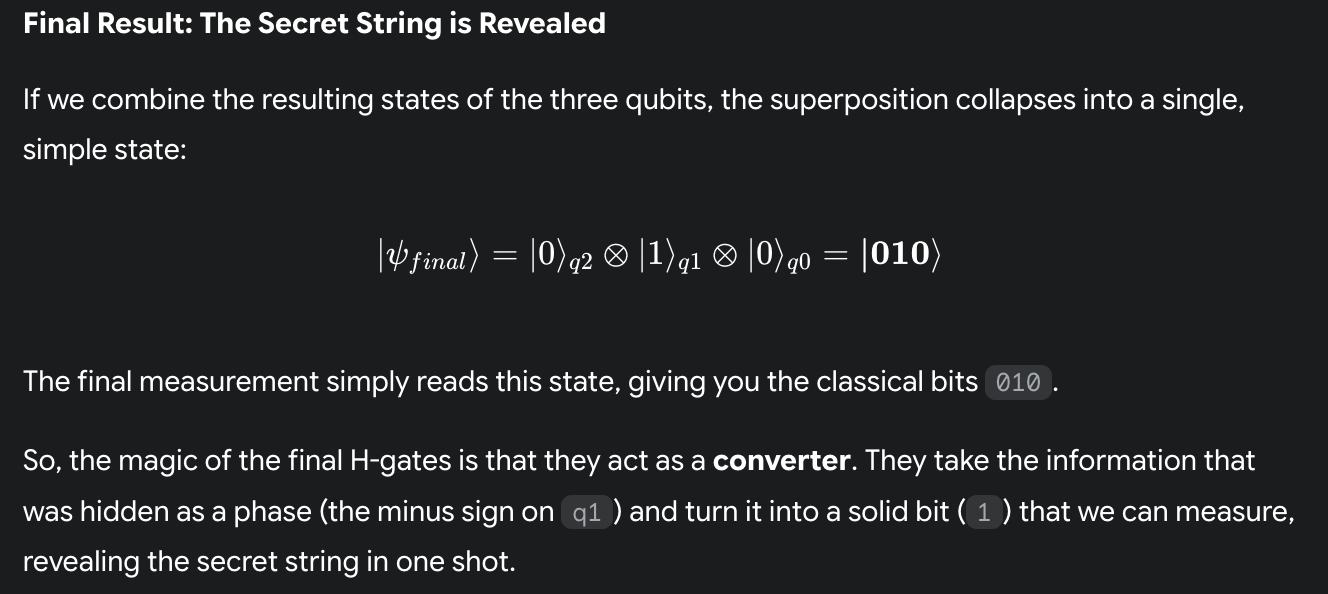
